In [4]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.transform import resize

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
Categories = ['Bus', 'Car']

flat_data_arr = []
target_arr = []

datadir = r"C:\Users\dell\Desktop\machine learning\SVM_PROJECT\Dataset copy"

In [6]:
for i in Categories:

    print(f'Loading... {i}')

    path = os.path.join(datadir, i)

    for img in os.listdir(path):

        img_array = imread(os.path.join(path, img))

        img_resize = resize(img_array, (150, 150, 3))

        flat_data_arr.append(img_resize.flatten())

        target_arr.append(Categories.index(i))

    print(f'{i} Loaded Successfully')

Loading... Bus
Bus Loaded Successfully
Loading... Car
Car Loaded Successfully


In [7]:
df = pd.DataFrame(flat_data_arr)

df['Target'] = target_arr

In [23]:
X = df.iloc[:, :-1]
X

,0,1,2,3,4,5,6,7,8,9,...,67490,67491,67492,67493,67494,67495,67496,67497,67498,67499
0,0.956836,0.956836,0.964679,0.956748,0.956748,0.964591,0.955521,0.955521,0.963365,0.956156,...,0.598633,0.778008,0.691893,0.606278,0.776166,0.689642,0.602622,0.781375,0.696104,0.607581
1,0.705079,0.837084,0.941106,0.703549,0.836794,0.938664,0.701107,0.834498,0.939563,0.703174,...,0.604527,0.613617,0.608673,0.600136,0.607515,0.602820,0.595100,0.617598,0.608273,0.598201
2,0.071806,0.078500,0.068306,0.102613,0.108600,0.098985,0.136285,0.144801,0.121420,0.064256,...,0.452994,0.529070,0.513320,0.465811,0.525391,0.507963,0.464596,0.530884,0.516551,0.470878
3,0.050379,0.212155,0.371699,0.053795,0.214445,0.378367,0.053270,0.210270,0.381015,0.057054,...,0.084643,0.199781,0.146173,0.076426,0.186026,0.145830,0.058000,0.174672,0.120307,0.061310
4,0.556665,0.537382,0.511956,0.629678,0.620172,0.601197,0.628205,0.620104,0.599409,0.629647,...,0.665508,0.693606,0.681950,0.666512,0.694884,0.683578,0.666662,0.683135,0.666902,0.645458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
196,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
197,0.996098,0.996098,0.996098,0.996103,0.996103,0.996103,0.996251,0.996251,0.996251,0.996263,...,0.374133,0.330927,0.382151,0.380303,0.351291,0.403005,0.398061,0.344094,0.410789,0.395363
198,0.068698,0.068698,0.068698,0.069680,0.069680,0.069680,0.053154,0.053415,0.052112,0.093198,...,0.408439,0.442869,0.406793,0.418819,0.439646,0.404352,0.416116,0.395360,0.360066,0.371830


In [9]:

y = df.iloc[:, -1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

In [11]:
model = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

In [12]:
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [13]:
print("Model Trained Successfully")

Model Trained Successfully


In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.75


In [16]:
print("Accuracy :", accuracy * 100)

Accuracy : 75.0


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.80      0.76        20
           1       0.78      0.70      0.74        20

    accuracy                           0.75        40
   macro avg       0.75      0.75      0.75        40
weighted avg       0.75      0.75      0.75        40



In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[16  4]
 [ 6 14]]


In [19]:
img_resize.flatten()

array([1.        , 1.        , 1.        , ..., 0.99011598, 0.99011598,
       0.99011598], shape=(67500,))

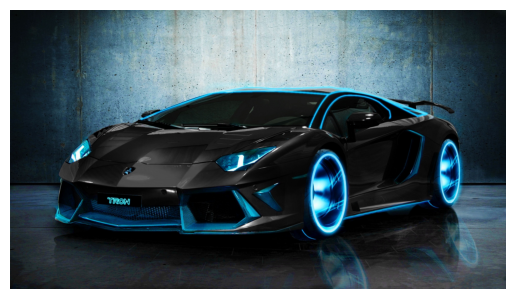

Prediction: Car


In [21]:
from skimage.io import imread
from skimage.transform import resize
import matplotlib.pyplot as plt

img = imread(r"C:\Users\dell\Desktop\machine learning\SVM_PROJECT\Dataset copy\Car\Image_13.jpg")

plt.imshow(img)
plt.axis('off')
plt.show()

img_resize = resize(img, (150,150,3)).flatten()

prediction = model.predict([img_resize])

print("Prediction:", Categories[prediction[0]])